In [171]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
from IPython.display import display
import yfinance as yf
import backtrader as bt
import pandas as pd

# Strat Backtesting

In [ ]:
""""
tickers = [
    # Tech
    "AAPL","MSFT","NVDA","AMD","INTC",
    # Finance
    "JPM","BAC","GS","MS","C",
    # Healthcare
    "JNJ","PFE","ABBV","MRK","UNH",
    # Energy
    "XOM","CVX","COP","SLB","EOG",
    # Consumer
    "WMT","COST","TGT","HD","LOW",
    # Communication
    "GOOGL","META","NFLX","DIS","CMCSA"
]
""

In [22]:
tickers = [
    # Tech
    "AAPL","MSFT",
    # Finance
    "JPM","BAC",
    # Healthcare
    "JNJ","PFE",
    # Energy
    "XOM","CVX",
]

In [23]:
datas = [yf.download(i, start='2015-01-01', end='2021-01-01') for i in tickers]
for data in datas:
    data.columns = [col[0] for col in data.columns.values]

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


```
class MyStrategy(bt.Strategy):
    params = (
    )
    
    def __init__(self):
        pass
    
    def log(self, msg, dt=None):
        pass
    def next(self):
        pass
    
    def notify_order(self, order):
        pass
    
    def notify_trade(self, trade):
        pass
```

In [4]:
def ma(dat, window):
    out = []
    block_inds = np.arange(len(dat))[window::window]
    for i in range(len(block_inds)):
        if block_inds[i] == block_inds[-1]:
            out.append(np.mean(dat[block_inds[-1]:]))
        else:
            out.append(np.mean(dat[block_inds[i]:block_inds[i+1]]))
    return np.array(out), block_inds

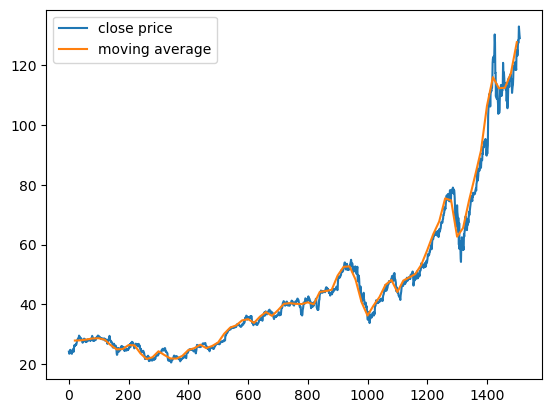

In [130]:
plt.plot( np.arange(len(datas[0]['Close'].to_numpy())), datas[0]['Close'].to_numpy(), label='close price' )
plt.plot( ma(datas[0]['Close'].to_numpy(),20)[1], ma(datas[0]['Close'].to_numpy(),20)[0], label='moving average' )
plt.legend()
plt.show()

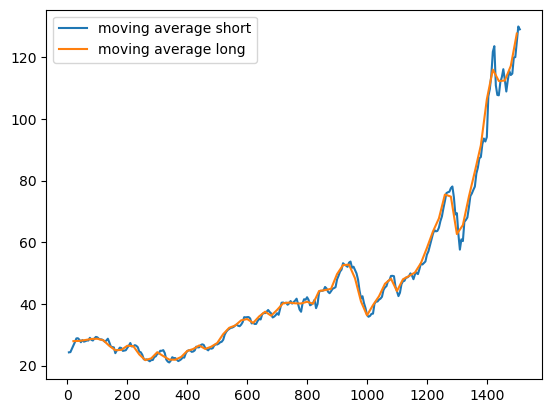

In [131]:
plt.plot( ma(datas[0]['Close'].to_numpy(),5)[1], ma(datas[0]['Close'].to_numpy(),5)[0], label='moving average short' )
plt.plot( ma(datas[0]['Close'].to_numpy(),20)[1], ma(datas[0]['Close'].to_numpy(),20)[0], label='moving average long' )
plt.legend()
plt.show()

In [5]:
class SmaCross(bt.SignalStrategy):
   '''
   This class implements a simple cross moving average (MA) signal buy strategy.
   sma1: short term moving average
   sma2: long term moving average
   When short-term MA crosses above long-term MA --> buy long.
   When short-term MA crosses below long-term MA --> sell long.
   WARNING: only works for a single stock
   '''
   def __init__(self):
       sma1, sma2 = bt.ind.SMA(period=5), bt.ind.SMA(period=20)
       crossover = bt.ind.CrossOver(sma1, sma2)
       self.signal_add(bt.SIGNAL_LONG, crossover)

In [6]:
class MultiSmaCross(bt.Strategy):
    '''
   This class implements a simple cross moving average (MA) signal buy strategy for a multi-stock market.
   Basically does SmaCross but for multiple tickers.
   sma1: short term moving average
   sma2: long term moving average
   When short-term MA crosses above long-term MA --> buy long.
   When short-term MA crosses below long-term MA --> sell long.
   WARNING: only works for a single stock
   '''
    params = (
        ('short_period', 5),
        ('long_period', 20),
    )
    def __init__(self):
        # Create SMA indicators for each data feed
        self.sma_short = [bt.ind.SMA(d, period=self.params.short_period) for d in self.datas]
        self.sma_long = [bt.ind.SMA(d, period=self.params.long_period) for d in self.datas]

    def next(self):
        # Loop through all data feeds (stocks)
        for i, d in enumerate(self.datas):
            pos = self.getposition(d)  # current position for this stock

            # If not in position, buy if short SMA crosses above long SMA
            if not pos:
                if self.sma_short[i][0] > self.sma_long[i][0]:
                    self.buy(data=d)
                    print(f'BUY {d._name} at {d.close[0]:.2f}')
            else:
                # Already in position, sell if short SMA crosses below long SMA
                if self.sma_short[i][0] < self.sma_long[i][0]:
                    self.sell(data=d)
                    print(f'SELL {d._name} at {d.close[0]:.2f}')

In [7]:
class MultiEmaCross(bt.Strategy):
    '''
   This class implements an exponential cross moving average (MA) signal buy strategy for a multi-stock market.
   Basically does MultiSmaCross but with exponential MA.
   sma1: short term moving average
   sma2: long term moving average
   When short-term MA crosses above long-term MA --> buy long.
   When short-term MA crosses below long-term MA --> sell long.
   WARNING: only works for a single stock
   '''
    params = (
        ('short_period', 5),
        ('long_period', 20),
    )
    def __init__(self):
        # Create SMA indicators for each data feed
        self.ema_short = [bt.ind.EMA(d, period=self.params.short_period) for d in self.datas]
        self.ema_long = [bt.ind.EMA(d, period=self.params.long_period) for d in self.datas]

    def next(self):
        # Loop through all data feeds (stocks)
        for i, d in enumerate(self.datas):
            pos = self.getposition(d)  # current position for this stock

            # If not in position, buy if short EMA crosses above long EMA
            if not pos:
                if self.ema_short[i][0] > self.ema_long[i][0]:
                    self.buy(data=d)
                    print(f'BUY {d._name} at {d.close[0]:.2f}')
            else:
                # Already in position, sell if short EMA crosses below long EMA
                if self.ema_short[i][0] < self.ema_long[i][0]:
                    self.sell(data=d)
                    print(f'SELL {d._name} at {d.close[0]:.2f}')

In [33]:
class MultiIndicator(bt.Strategy):
    params = dict(
        sma_short=5,
        sma_long=20,
        rsi_period=14,
        rsi_oversold=30,
        rsi_overbought=40
    )

    def __init__(self):
        self.sma_short = []
        self.sma_long = []
        self.rsi = []
        self.macd = []

        # create indicators for EACH stock
        for d in self.datas:
            self.sma_short.append(bt.ind.SMA(d, period=self.params.sma_short))
            self.sma_long.append(bt.ind.SMA(d, period=self.params.sma_long))
            self.rsi.append(bt.ind.RSI(d, period=self.params.rsi_period))
            self.macd.append(bt.ind.MACD(d))

    def next(self):
        for i, d in enumerate(self.datas):

            pos = self.getposition(d)

            sma_bull = self.sma_short[i][0] > self.sma_long[i][0]
            rsi_bull = self.rsi[i][0] < self.params.rsi_oversold
            macd_bull = self.macd[i].macd[0] > self.macd[i].signal[0]

            # BUY condition (all indicators agree)
            if not pos:
                if self.sma_short[i] > self.sma_long[i] and self.rsi[i] < 40:
                    self.buy(data=d)

            # SELL condition
            sma_bear = self.sma_short[i][0] < self.sma_long[i][0]
            rsi_bear = self.rsi[i][0] > self.params.rsi_overbought
            macd_bear = self.macd[i].macd[0] < self.macd[i].signal[0]

            if pos and sma_bear and rsi_bear and macd_bear:
                self.sell(data=d)

In [34]:
cerebro = bt.Cerebro()
cerebro.addstrategy(MultiIndicator)
for data in datas:
    data_feed = bt.feeds.PandasData(dataname=data,
        open='Open',
        high='High',
        low='Low',
        close='Close',
        volume='Volume',
        openinterest=None)
    cerebro.adddata(data_feed)
cerebro.addanalyzer(bt.analyzers.SharpeRatio, _name='sharpe')
cerebro.addanalyzer(bt.analyzers.DrawDown, _name='drawdown')
cerebro.addanalyzer(bt.analyzers.Returns, _name='returns')
cerebro.addanalyzer(bt.analyzers.TradeAnalyzer, _name='trades')
cerebro.broker.setcash(1000)
res = cerebro.run()
strat = res[0]

In [35]:
print(strat.analyzers.sharpe.get_analysis())
print(strat.analyzers.drawdown.get_analysis())
print(strat.analyzers.returns.get_analysis())
print(strat.analyzers.trades.get_analysis())

OrderedDict({'sharperatio': -1.124297635706472})
AutoOrderedDict({'len': 709, 'drawdown': 3.3022598360678264, 'moneydown': 33.50400313418447, 'max': AutoOrderedDict({'len': 709, 'drawdown': 5.474034462559266, 'moneydown': 55.538351581868824})})
OrderedDict({'rtot': -0.0191073510304434, 'ravg': -1.2645500351054532e-05, 'rnorm': -0.003181594057139871, 'rnorm100': -0.3181594057139871})
AutoOrderedDict({'total': AutoOrderedDict({'total': 26, 'open': 0, 'closed': 26}), 'streak': AutoOrderedDict({'won': AutoOrderedDict({'current': 3, 'longest': 6}), 'lost': AutoOrderedDict({'current': 0, 'longest': 3})}), 'pnl': AutoOrderedDict({'gross': AutoOrderedDict({'total': -18.925962719307787, 'average': -0.7279216430502995}), 'net': AutoOrderedDict({'total': -18.925962719307787, 'average': -0.7279216430502995})}), 'won': AutoOrderedDict({'total': 17, 'pnl': AutoOrderedDict({'total': 21.48719296611676, 'average': 1.263952527418633, 'max': 5.538158555893148})}), 'lost': AutoOrderedDict({'total': 9, 'pn

In [36]:
cerebro.broker.getvalue()

981.0740372806922

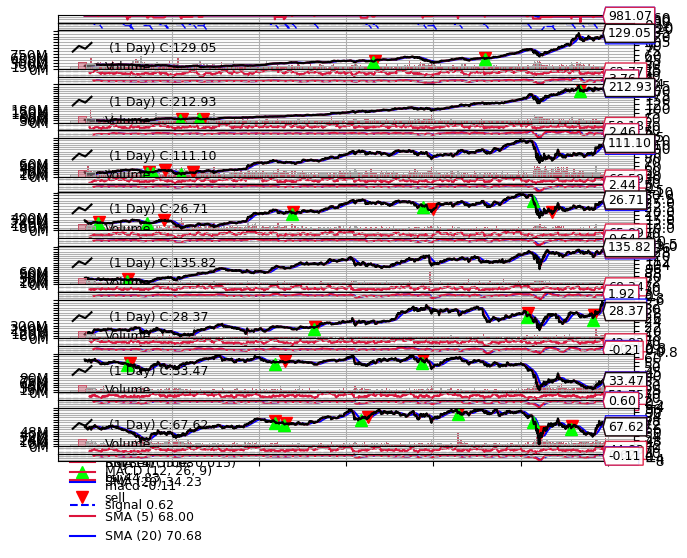

[[<Figure size 640x480 with 34 Axes>]]

In [37]:
%matplotlib inline
cerebro.plot(iplot=False)

# Indicators

### On-Balance Volume
- volume indicator

In [64]:
def calc_obv(dataf):
    tobv = dataf['Volume'].to_numpy()[0]
    obv = [tobv]
    for i in range(1,len(dataf)-1):
        if dataf['Close'].to_numpy()[i] > dataf['Close'].to_numpy()[i-1]:
            tobv += dataf['Volume'].to_numpy()[i]
            obv.append(tobv)
        elif dataf['Close'].to_numpy()[i] < dataf['Close'].to_numpy()[i-1]:
            tobv -= dataf['Volume'].to_numpy()[i]
            obv.append(tobv)
        else:
            obv.append(obv[-1])
    obv = np.array(obv)
    return obv

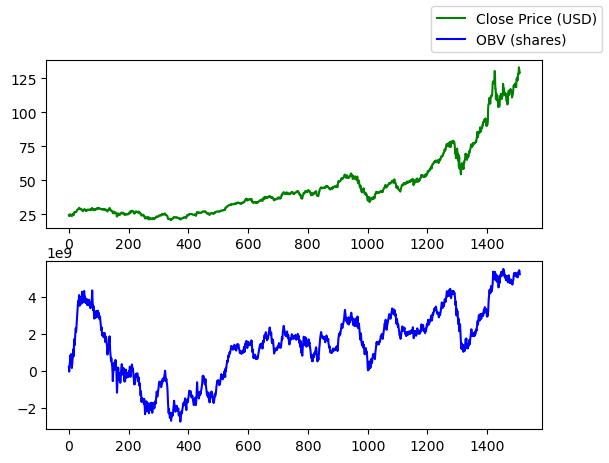

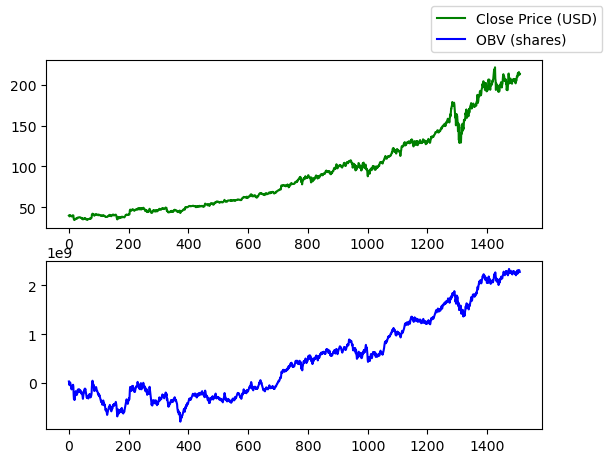

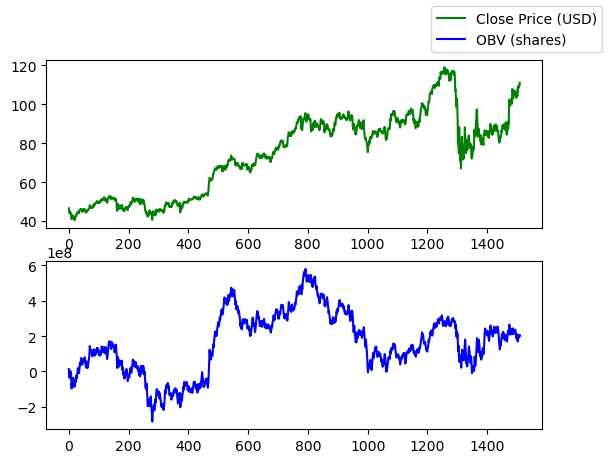

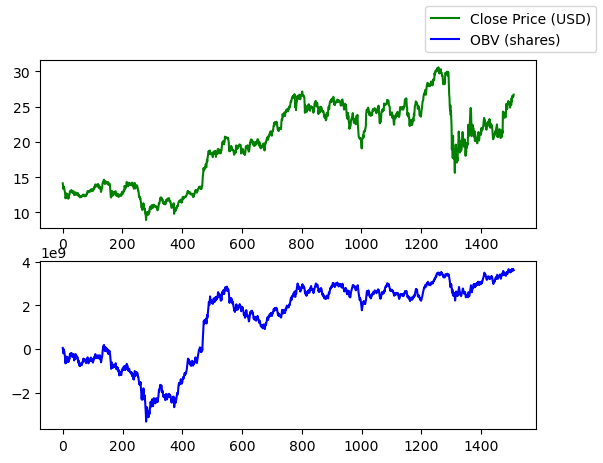

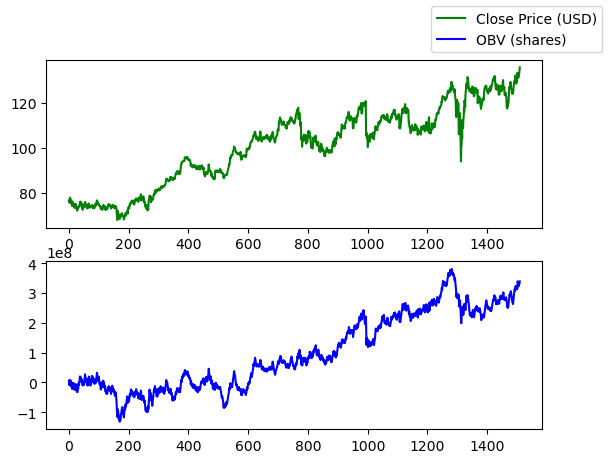

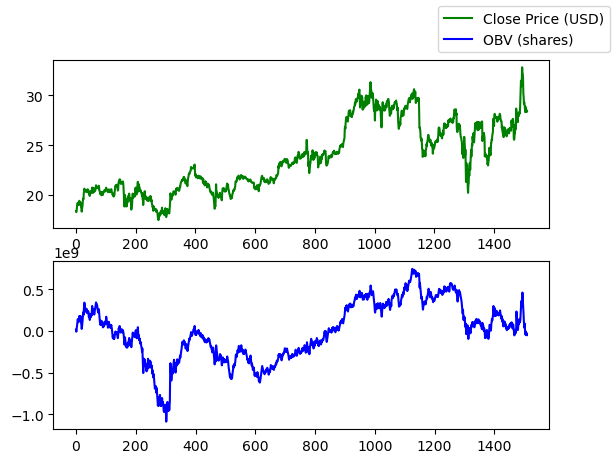

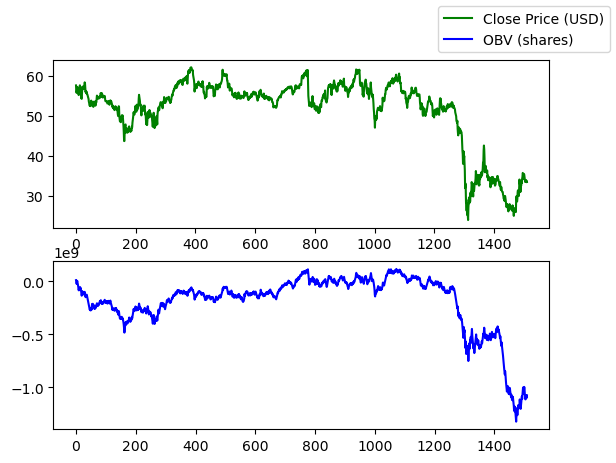

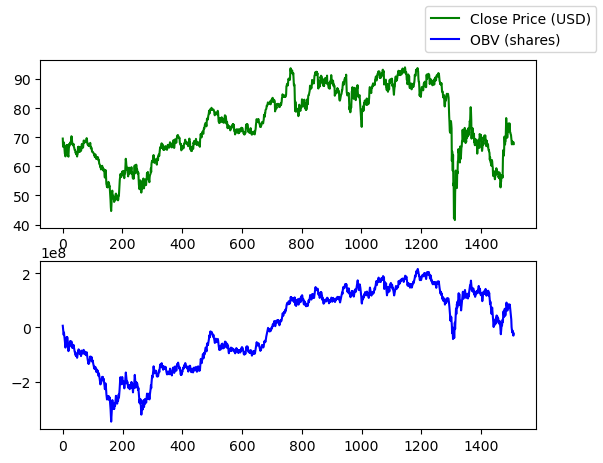

In [147]:
for d in datas:
    fig, ax = plt.subplots(2, 1)
    ax[0].plot(np.arange(len(d['Close'].to_numpy())), d['Close'].to_numpy(), c='g', label='Close Price (USD)')
    ax[1].plot(np.arange(len(calc_obv(d))), calc_obv(d), c='b', label='OBV (shares)')
    fig.legend()
    plt.show()

### Accumulation/Distribution Line
- volume indicator

In [73]:
datas[0].iloc[3]

Close     2.386495e+01
High      2.396462e+01
Low       2.363239e+01
Open      2.374313e+01
Volume    1.604236e+08
Name: 2015-01-07 00:00:00, dtype: float64

In [76]:
def mfm(day_dat):
    return ( (day_dat['Close']-day_dat['Low']) - (day_dat['High']-day_dat['Close']) ) / (day_dat['High']-day_dat['Low'])

def ad_line(dat):
    t_ad = 0
    ads = []
    for i in range(len(dat)):
        d_mfv = mfm(dat.iloc[i])*dat.iloc[i]['Volume']
        t_ad += d_mfv
        ads.append(t_ad)
    return np.array(ads)


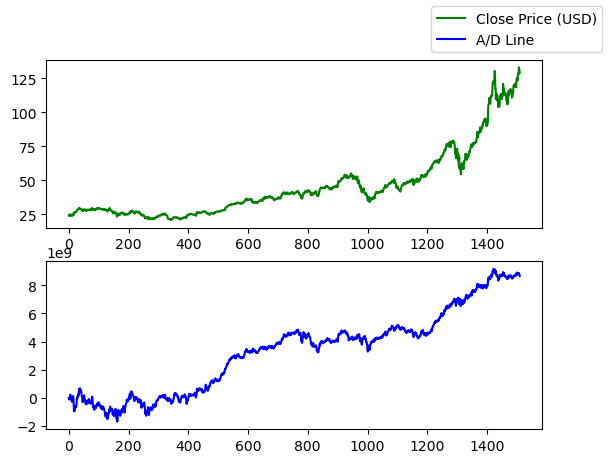

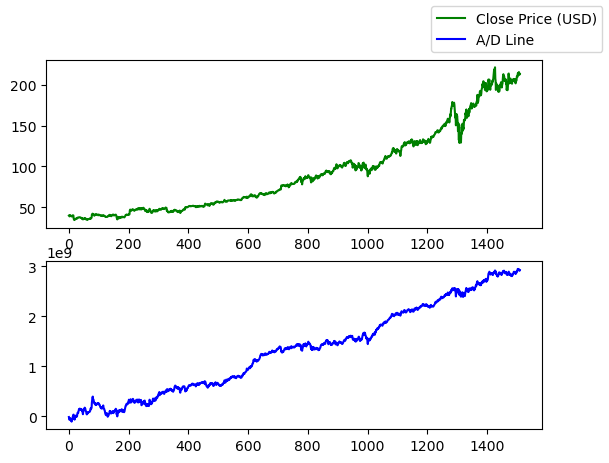

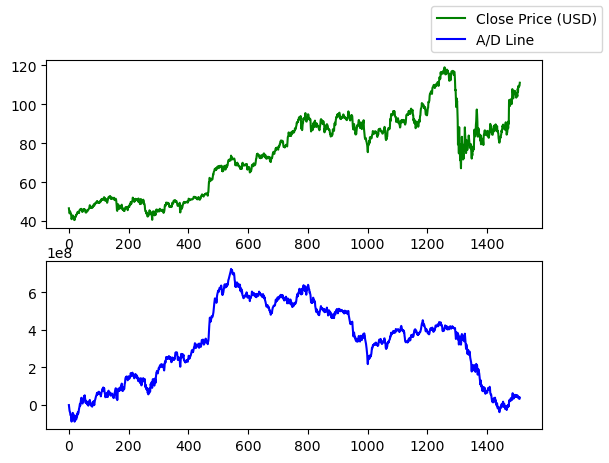

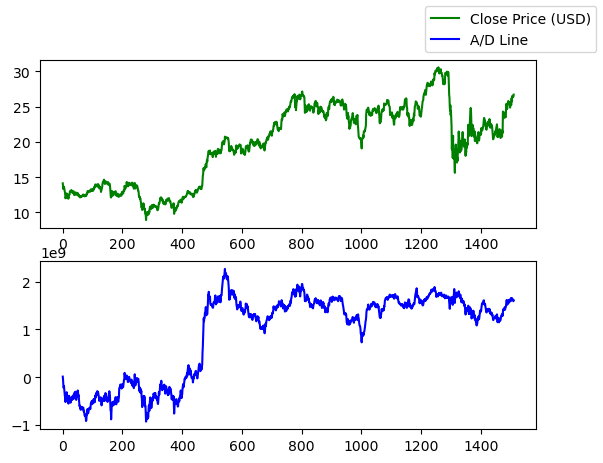

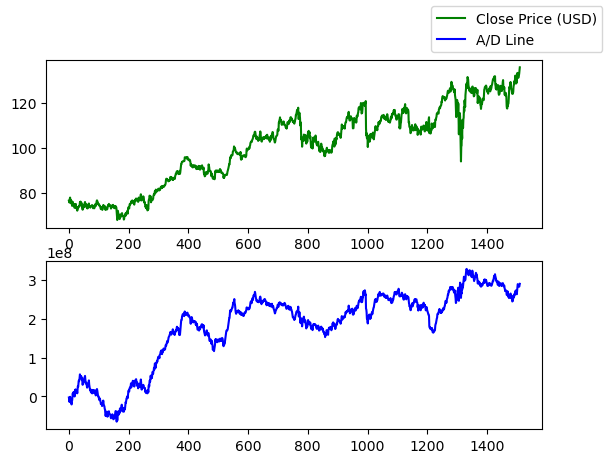

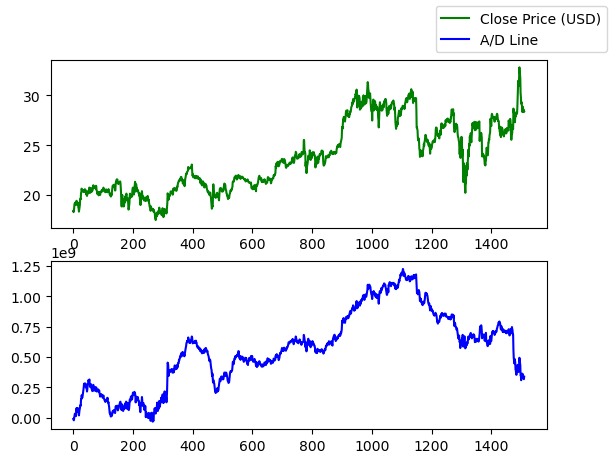

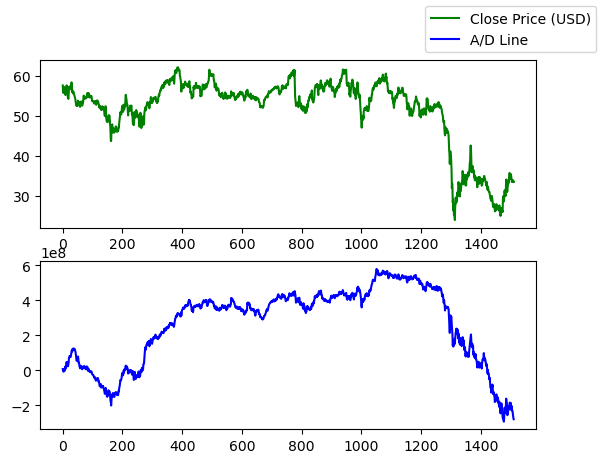

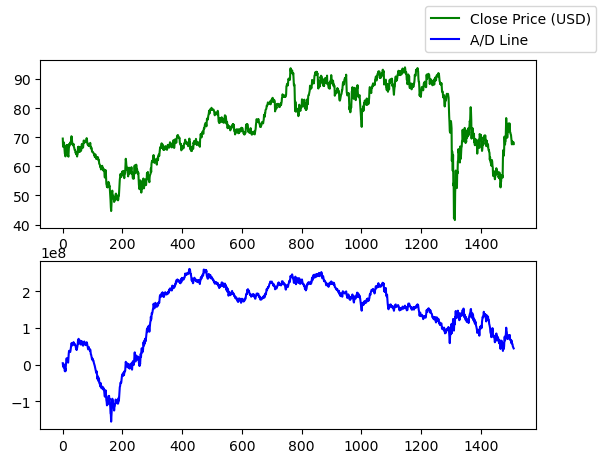

In [148]:
for d in datas:
    fig, ax = plt.subplots(2, 1)
    ax[0].plot(np.arange(len(d['Close'].to_numpy())), d['Close'].to_numpy(), c='g', label='Close Price (USD)')
    ax[1].plot(np.arange(len(ad_line(d))), ad_line(d), c='b', label='A/D Line')
    fig.legend()
    plt.show()

### Average Directional Index
- trend strength indicator

In [121]:
np.mod(28,14)

np.int64(0)

In [ ]:
def av_dir_index(dat, p_length):
    adx_vals = []
    tr_s = 0
    pdm_s = 0
    mdm_s = 0
    dx_vals = []

    for day in range(1, len(dat)):

        # define current high,low and previous close 
        high = dat.iloc[day]['High']
        low = dat.iloc[day]['Low']
        close_prev = dat.iloc[day-1]['Close']

        # get tr
        tr = max(
            high - low,
            abs(high - close_prev),
            abs(low - close_prev)
        )

        # get +/- DM
        up_move = high - dat.iloc[day-1]['High']
        down_move = dat.iloc[day-1]['Low'] - low
        pdm = up_move if (up_move > down_move and up_move > 0) else 0
        mdm = down_move if (down_move > up_move and down_move > 0) else 0

        # if we haven't accumulated > p_length days 
        if day <= p_length:
            tr_s += tr
            pdm_s += pdm
            mdm_s += mdm
            continue

        # do Wilder smoothing
        tr_s = tr_s - (tr_s / p_length) + tr
        pdm_s = pdm_s - (pdm_s / p_length) + pdm
        mdm_s = mdm_s - (mdm_s / p_length) + mdm

        plus_di = 100 * (pdm_s / tr_s)
        minus_di = 100 * (mdm_s / tr_s)

        dx = 100 * abs(plus_di - minus_di) / (plus_di + minus_di)
        dx_vals.append(dx)

        # compute ADX
        if len(dx_vals) == p_length:
            adx_vals.append(np.mean(dx_vals))
        elif len(dx_vals) > p_length:
            prev_adx = adx_vals[-1]
            adx = ((prev_adx * (p_length - 1)) + dx) / p_length
            adx_vals.append(adx)

    return np.array(adx_vals)
        

            

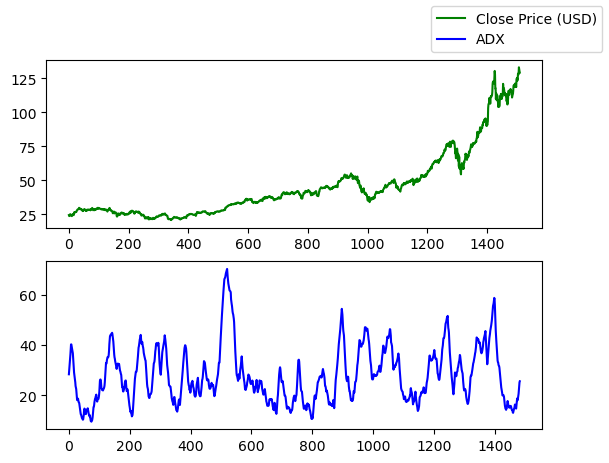

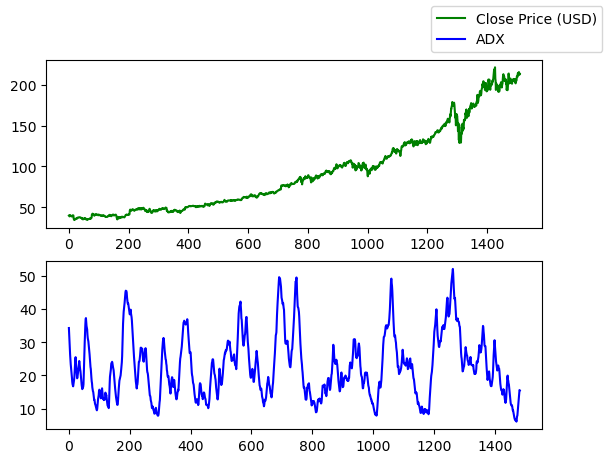

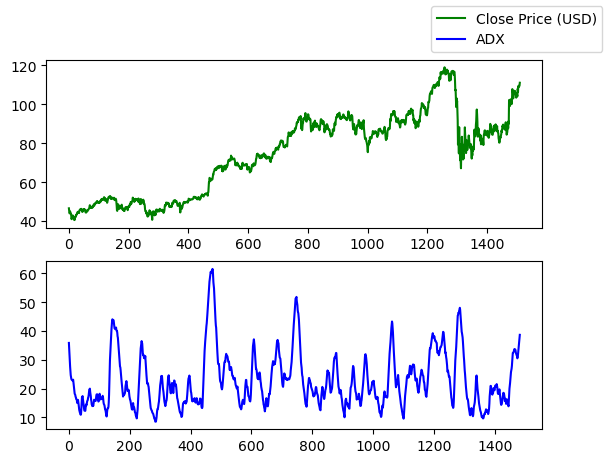

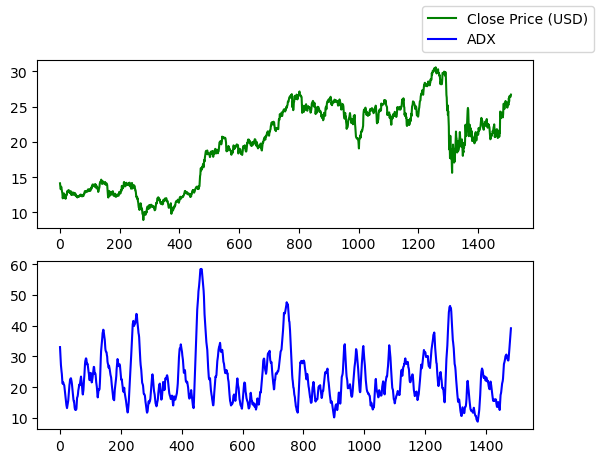

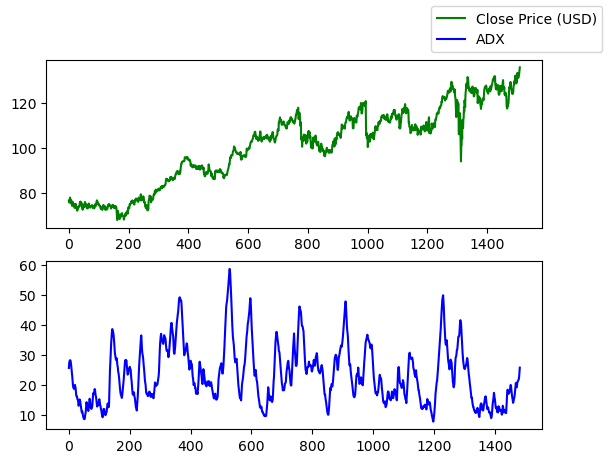

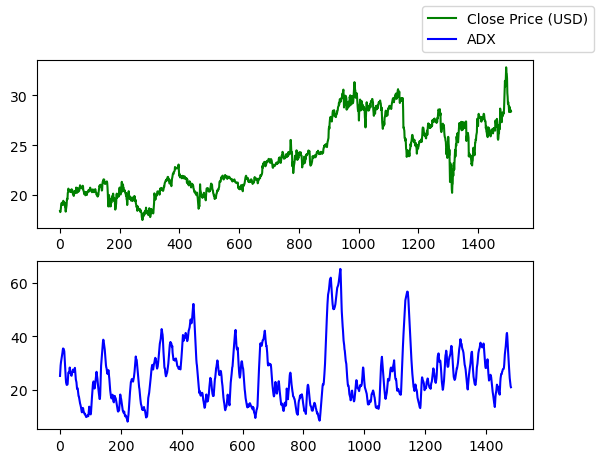

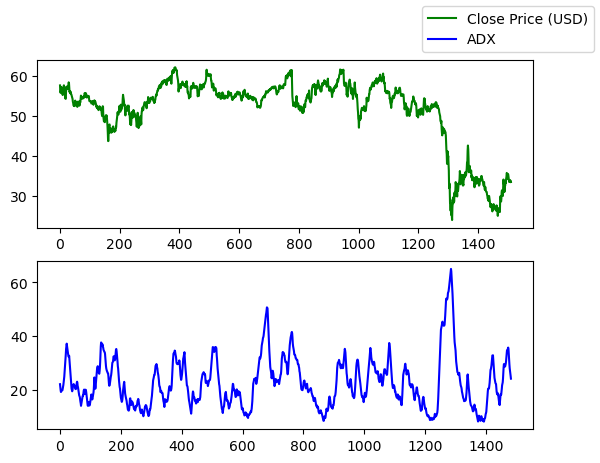

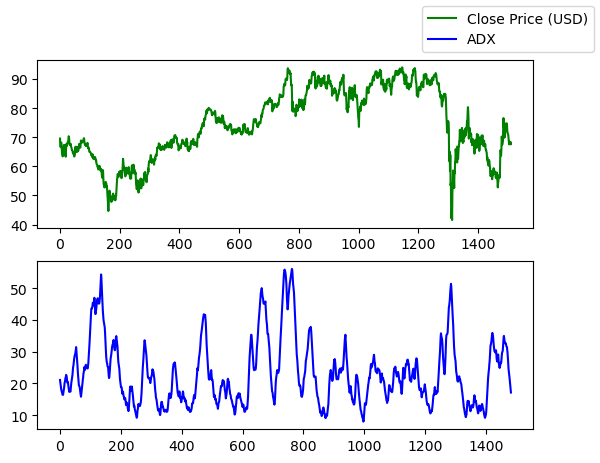

In [149]:
for d in datas:
    fig, ax = plt.subplots(2, 1)
    ax[0].plot(np.arange(len(d['Close'].to_numpy())), d['Close'].to_numpy(), c='g', label='Close Price (USD)')
    ax[1].plot(np.arange(len(av_dir_index(d, 14))), av_dir_index(d, 14), c='b', label='ADX')
    fig.legend()
    plt.show()

### Aroon Indicator
- trend indicator

In [153]:
def aroon_oscillator(dat, p_length):
    aos = []
    aus = []
    ads = []
    for day in range(len(dat)):
        if day < p_length:
            None
        else:
            t_au = (p_length - (p_length - np.argmax(dat.iloc[day-p_length:day]['High'])))*(100/p_length)
            t_ad = (p_length - (p_length - np.argmin(dat.iloc[day-p_length:day]['Low'])))*(100/p_length)
            t_ao = t_au - t_ad
            aos.append(t_ao)
            aus.append(t_au)
            ads.append(t_ad)
    return np.array(aos),np.array(aus),np.array(ads)

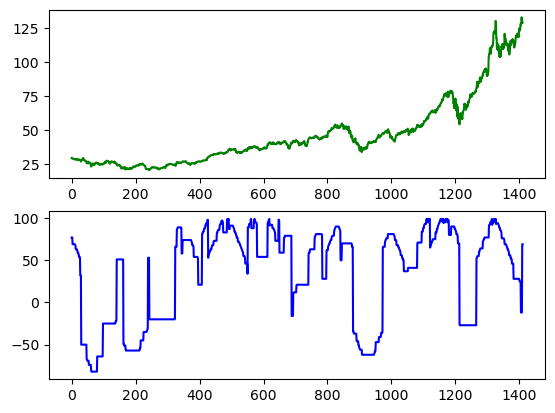

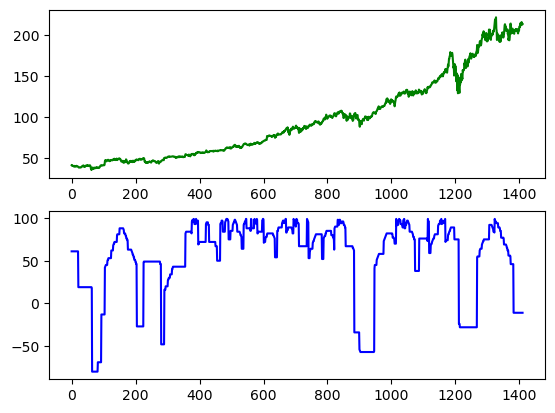

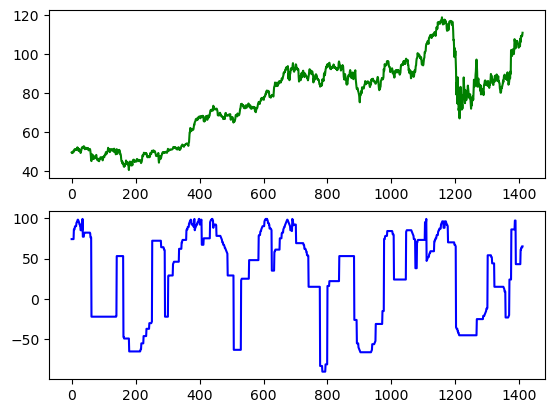

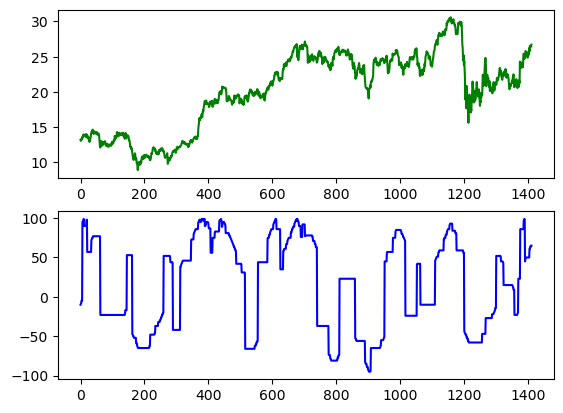

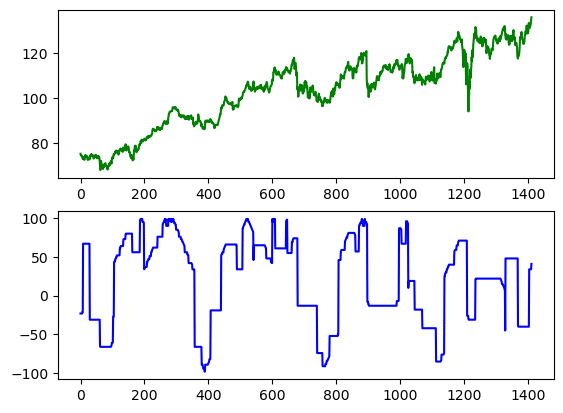

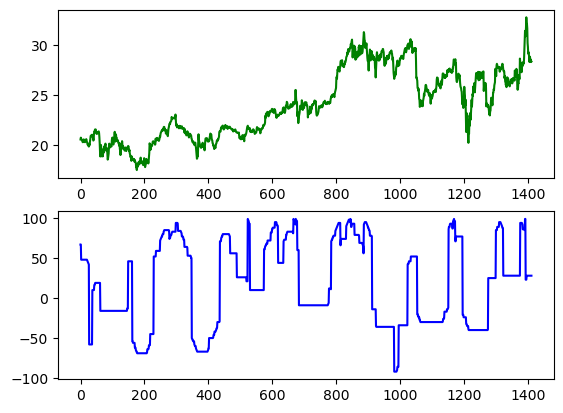

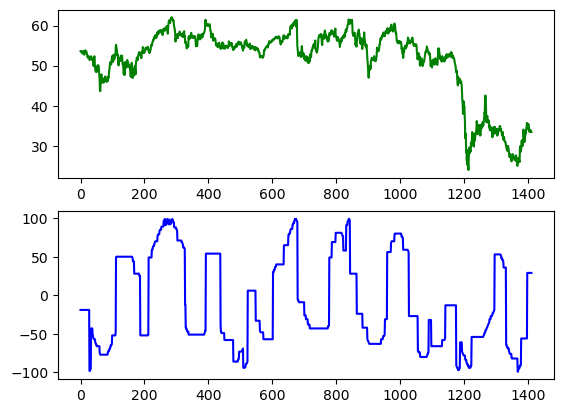

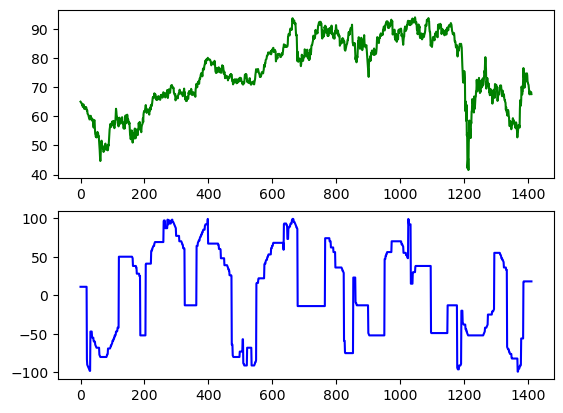

In [181]:
aroon_period = 100
for d in datas:
    fig, ax = plt.subplots(2, 1)
    ax[0].plot(np.arange(len(d.iloc[aroon_period:])), d.iloc[aroon_period:]['Close'], c='g', label='Close price (USD)')
    ax[1].plot( np.arange(len(aroon_oscillator(d,aroon_period)[0])), aroon_oscillator(d,aroon_period)[0], c='b', label='Aroon Oscillator')

### Moving Average Convergence Distance (MACD)
- momentum and trend indicator

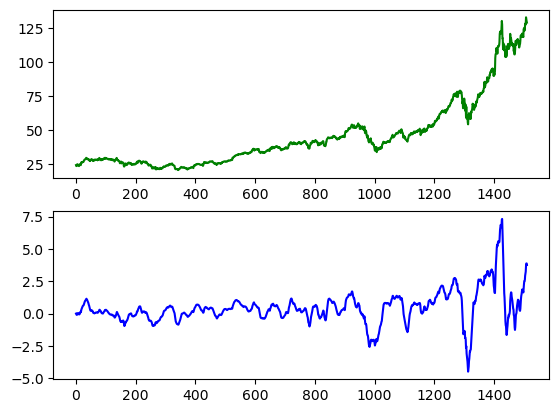

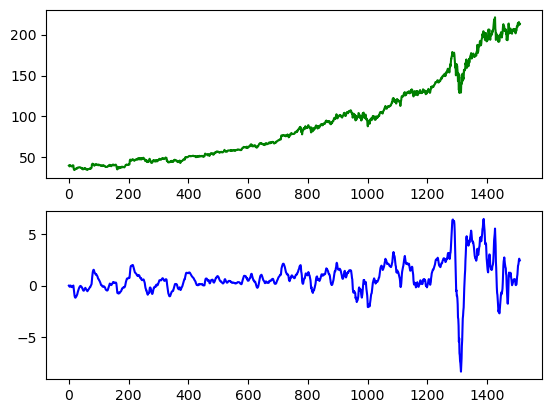

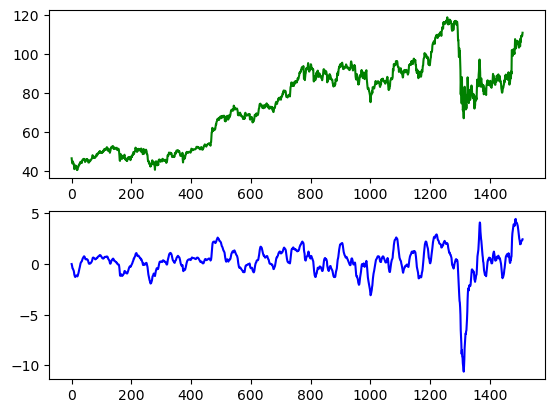

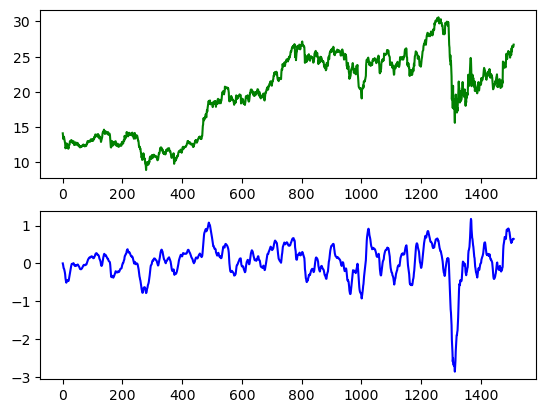

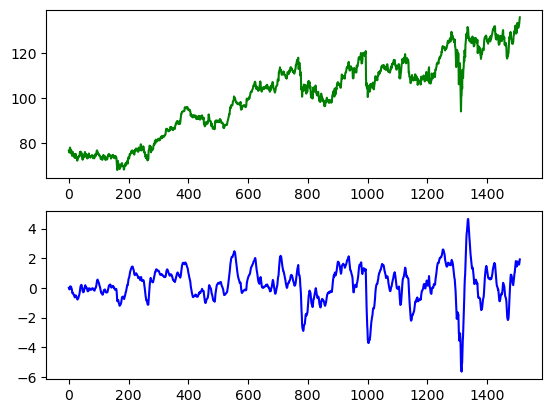

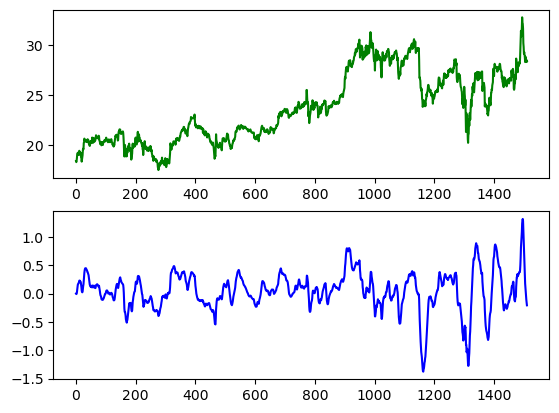

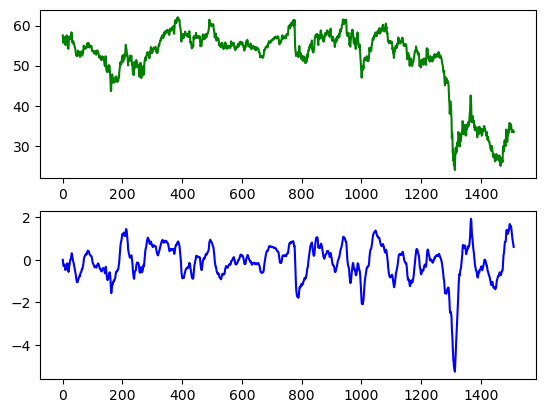

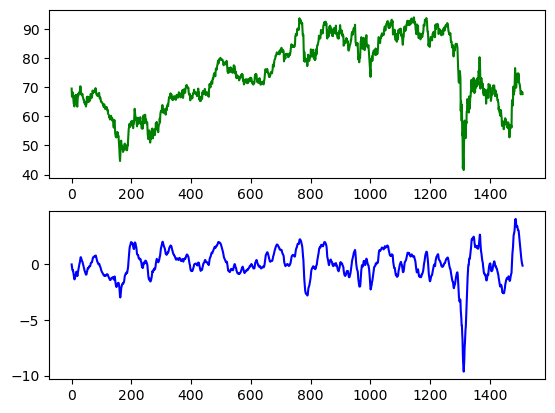

In [182]:
for d in datas:
    fig, ax = plt.subplots(2, 1)
    cp = d['Close']
    macd = d['Close'].ewm(span=12, adjust=False).mean().to_numpy() - d['Close'].ewm(span=26, adjust=False).mean().to_numpy()
    ax[0].plot(np.arange(len(cp)), cp, c='g')
    ax[1].plot(np.arange(len(macd)), macd,c='b')

### Relative Strength Indicator (RSI)
- momentum oscillator

In [183]:
def calc_rsi(close, period=14):
    close = np.asarray(close)

    delta = np.diff(close)

    gain = np.maximum(delta, 0)
    loss = np.maximum(-delta, 0)

    avg_gain = np.zeros_like(close)
    avg_loss = np.zeros_like(close)

    # initial average
    avg_gain[period] = np.mean(gain[:period])
    avg_loss[period] = np.mean(loss[:period])

    # Wilder smoothing
    for i in range(period+1, len(close)):
        avg_gain[i] = (avg_gain[i-1]*(period-1) + gain[i-1]) / period
        avg_loss[i] = (avg_loss[i-1]*(period-1) + loss[i-1]) / period

    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

/tmp/ipykernel_39911/621329218.py:21: RuntimeWarning: invalid value encountered in divide
  rs = avg_gain / avg_loss


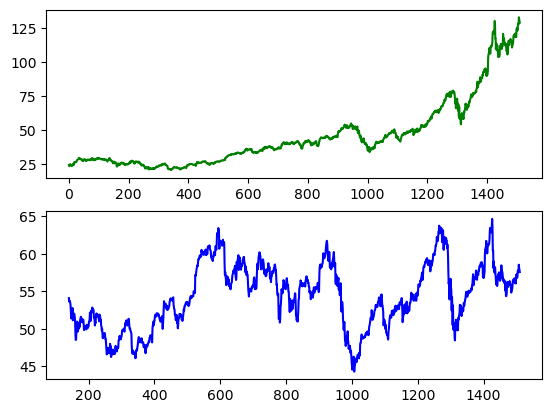

In [193]:
fig, ax = plt.subplots(2, 1)
ax[0].plot(np.arange(len(datas[0]['Close'])), datas[0]['Close'], c='g')
ax[1].plot(np.arange(len(calc_rsi(datas[0]['Close'].to_numpy()))),calc_rsi(datas[0]['Close'].to_numpy(),14*10),c='b')